In [ ]:
import kagglehub
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sklearn
import seaborn as sns

from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Configuration pour les graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.11.14
Platform: Linux-6.17.0-20-generic-x86_64-with-glibc2.39
NumPy: 2.4.3
Pandas: 3.0.1
Scikit-learn: 1.8.0




====== DATASET Risque sur les crédits ======



Nombre de lignes : 32581
Nombre de colonnes : 12

====== Liste des colonnes et données manquantes ======
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

====== NETTOYAGE DES DONNÉES ======
Doublons supprimés : 165
Lignes après suppression des données aberrantes : 31522

====== TRAITEMENT DES VALEURS MANQUANTES ======
Médiane utilisée pour le taux d'intérêt : 10.99%
Vérification finale des manques :
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
l

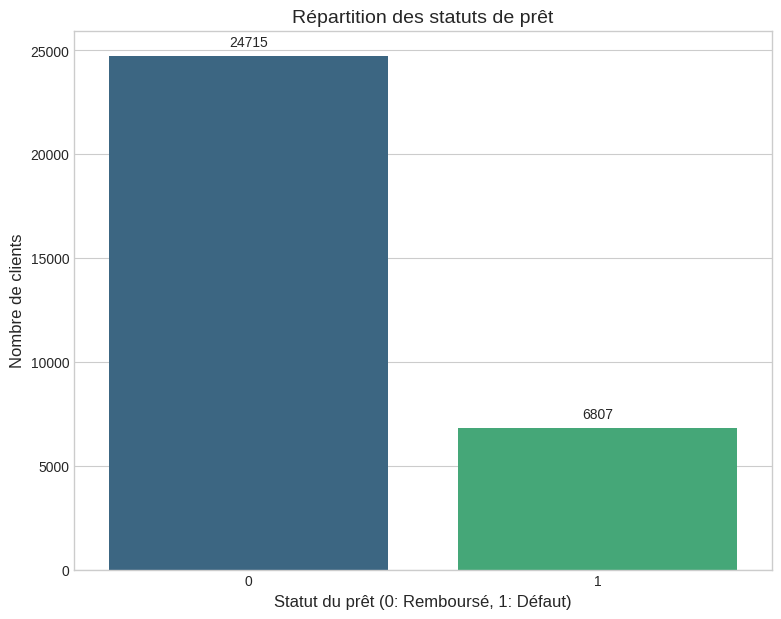

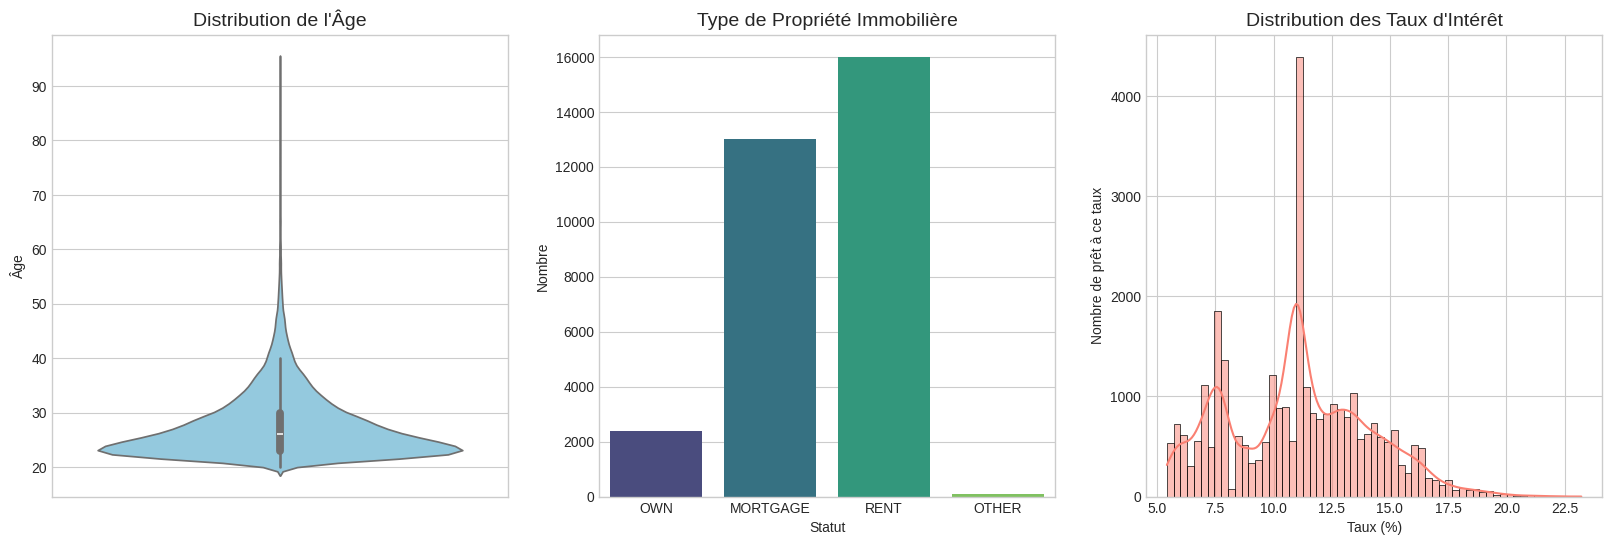

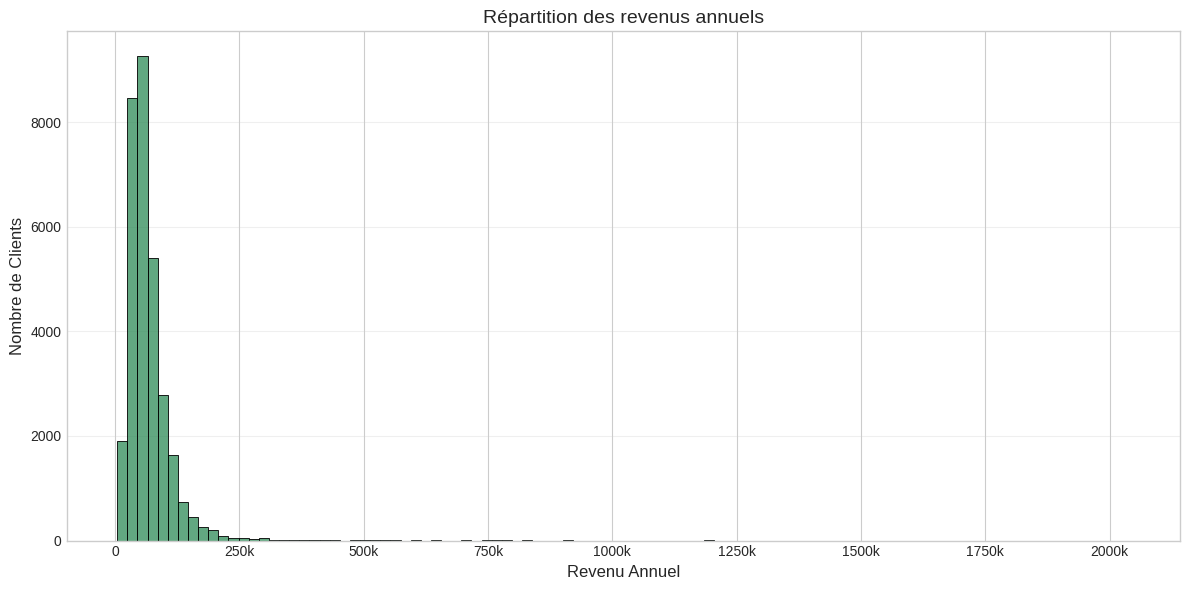

In [ ]:
# Dataset : CREDIT RISK depuis Kaggle
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
credit_dataset = pd.read_csv('credit_risk_dataset.csv')

print("\n============================================")
print("\n====== DATASET Risque sur les crédits ======")
print("\n============================================")

print("\n\nNombre de lignes :", credit_dataset.shape[0])
print("Nombre de colonnes :", credit_dataset.shape[1])

# Loan status : 0 => prêt remboursé, 1 => défaut remboursement

# Vérification données manquantes : 
print("\n====== Liste des colonnes et données manquantes ======")
print(credit_dataset.isnull().sum())

print("\n====== NETTOYAGE DES DONNÉES ======")

# Suppression des doublons
initial_count = len(credit_dataset)
credit_dataset = credit_dataset.drop_duplicates()
print(f"Doublons supprimés : {initial_count - len(credit_dataset)}")

# Suppression des valeurs aberrantes (Âge > 100 et Nombre d'années travaillées > 60 ans)
# On écrase le dataset avec les données filtrées
credit_dataset = credit_dataset[credit_dataset['person_age'] < 100]
credit_dataset = credit_dataset[credit_dataset['person_emp_length'] < 60]
print(f"Lignes après suppression des données aberrantes : {len(credit_dataset)}")

print("\n====== TRAITEMENT DES VALEURS MANQUANTES ======")

# Ajout de la médiane dans le loan_int_rate
# Calcule de la médiane sur les données existantes
median_int_rate = credit_dataset['loan_int_rate'].median()
credit_dataset['loan_int_rate'] = credit_dataset['loan_int_rate'].fillna(median_int_rate)

# Imputation de la durée d'emploi par la médiane
median_emp_length = credit_dataset['person_emp_length'].median()
credit_dataset['person_emp_length'] = credit_dataset['person_emp_length'].fillna(median_emp_length)

print(f"Médiane utilisée pour le taux d'intérêt : {median_int_rate}%")
print("Vérification finale des manques : ", credit_dataset.isnull().sum())

plt.figure(figsize=(9,7))
# Création du graphique à barres
graph_bar = sns.countplot(
    x='loan_status', 
    data=credit_dataset,
    hue='loan_status',
    palette='viridis',
    legend=False
)

plt.title('Répartition des statuts de prêt', fontsize=14)
plt.xlabel('Statut du prêt (0: Remboursé, 1: Défaut)', fontsize=12)
plt.ylabel('Nombre de clients', fontsize=12)

for patch in graph_bar.patches:
    graph_bar.annotate(f'{int(patch.get_height())}', (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
    
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Violin graph pour l'âge
sns.violinplot(ax=axes[0], y=credit_dataset['person_age'], color="skyblue")
axes[0].set_title("Distribution de l'Âge", fontsize=14)
axes[0].set_ylabel("Âge")

# 2. Répartition de la PROPRIÉTÉ (Count Plot)
sns.countplot(
    ax=axes[1], 
    x='person_home_ownership', 
    data=credit_dataset, 
    palette="viridis",
    hue='person_home_ownership',
    legend=False
)
axes[1].set_title("Type de Propriété Immobilière", fontsize=14)
axes[1].set_xlabel("Statut")
axes[1].set_ylabel("Nombre")

# 3. Répartition du TAUX D'INTÉRÊT (Histogramme + KDE)
sns.histplot(
    ax=axes[2], 
    x=credit_dataset['loan_int_rate'], 
    kde=True, 
    color="salmon"
)
axes[2].set_title("Distribution des Taux d'Intérêt", fontsize=14)
axes[2].set_xlabel("Taux (%)")
axes[2].set_ylabel("Nombre de prêt à ce taux")

# 4. Répartition des revenus
plt.figure(figsize=(12, 6))

# Histogramme avec 100 colonnes (bins) pour essayer de capter les revenus isolés
sns.histplot(credit_dataset['person_income'], kde=False, color="seagreen", bins=100)

# Formatage des nombres sur l'axe X pour éviter les notations scientifiques (ex: 1e6)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

plt.title("Répartition des revenus annuels", fontsize=14)
plt.xlabel("Revenu Annuel", fontsize=12)
plt.ylabel("Nombre de Clients", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Liste des colonnes numériques :

credit_dataset_num_cols = [
    "person_age", 
    "person_income", 
    "person_emp_length", 
    "loan_amnt", 
    "loan_int_rate", 
    "loan_percent_income", 
    "cb_person_cred_hist_length"
]

# Liste des colonnes contenant du texte uniquement : 

cat_cols = [
    "person_home_ownership", 
    "loan_intent", 
    "loan_grade", 
    "cb_person_default_on_file"
]


In [4]:
# 1. Pipeline pour les données numériques
num_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Gère les NaN
    ('scaler', StandardScaler())                   # Standardisation des data
])

# 2. Pipeline pour les données catégorielles:
#  SimpleImputer : strategy: contant => Remplace les valeurs textuelles manquantes par la même valeur 'fill_value', donc missing
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 3. Combinaison des deux
preprocess = ColumnTransformer(
    transformers=[
        ('num', num_preprocess, credit_dataset_num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

## Test des modèles 

### 1. Régression Logistique
### 2. Random Forest
### 3. XGBoost

In [ ]:
# --- SÉPARATION DES DONNÉES ---
X = credit_dataset.drop('loan_status', axis=1)
y = credit_dataset['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

trained_pipelines = {}

# --- PARTIE 1 : OPTIMISATION RANDOM FOREST (n_estimators) ---
best_rf_acc = 0
n_large = 20

for n in range(20, 105, 5): 
    clf_rf = Pipeline(steps=[('preprocessor', preprocess), 
                              ('classifier', RandomForestClassifier(n_estimators=n, random_state=42))])
    clf_rf.fit(X_train, y_train)
    current_acc = clf_rf.score(X_test, y_test)
    print(f"n_estimators : {n:3} | Accuracy: {current_acc:.4f}")
    
    if current_acc > best_rf_acc:
        best_rf_acc = current_acc
        n_large = n

print(f"-> Zone repérée autour de n={n_large}")

# --- OPTIMISATION FINE (Step de 1 entre n-3 et n+3) ---
range_fine = range(max(1, n_large - 3), n_large + 4) 

for n in range_fine:
    clf_rf = Pipeline(steps=[('preprocessor', preprocess), 
                              ('classifier', RandomForestClassifier(n_estimators=n, random_state=42))])
    clf_rf.fit(X_train, y_train)
    current_acc = clf_rf.score(X_test, y_test)
    print(f"n_estimators :   {n:3} | Accuracy: {current_acc:.4f}")
    
    if current_acc >= best_rf_acc:
        best_rf_acc = current_acc
        best_n = n
        trained_pipelines["Random Forest"] = clf_rf

print(f"\n=> RESULTAT FINAL : Meilleur n_estimators = {best_n} avec {best_rf_acc:.4f} d'accuracy.")


# --- PARTIE 2 : OPTIMISATION XGBOOST ---
print("\n====== 2. OPTIMISATION XGBOOST ======")
xgb_metrics = ['logloss', 'error', 'auc', 'aucpr'] # Metrics qui ne sert que pour la classification binaire, les autres ne seront pas utile
best_xgb_auc = 0
best_metric = ""

for metric in xgb_metrics:
    xgb_model = XGBClassifier(eval_metric=metric, random_state=42)
    clf_xgb = Pipeline(steps=[('preprocessor', preprocess), ('classifier', xgb_model)])
    
    clf_xgb.fit(X_train, y_train)
    
    # Pour XGBoost, on juge sur le ROC-AUC (plus précis pour le risque crédit)
    current_auc = roc_auc_score(y_test, clf_xgb.predict_proba(X_test)[:, 1])
    print(f"Metric: {metric:8} | ROC-AUC: {current_auc:.4f}")
    
    if current_auc > best_xgb_auc:
        best_xgb_auc = current_auc
        best_metric = metric
        # On ne garde que le meilleur pipeline XGBoost
        trained_pipelines["XGBoost"] = clf_xgb

print(f"=> Meilleur XGBoost : metric={best_metric} ({best_xgb_auc:.4f})")


# --- PARTIE 3 : RÉGRESSION LOGISTIQUE ---
print("\n====== 3. RÉGRESSION LOGISTIQUE ======")
iterations = [10, 20, 50, 70, 100, 300, 500, 750, 1000]
best_log_acc = 0
results_log = []

for i in iterations:
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    
    clf_log = Pipeline(steps=[
        ('preprocessor', preprocess), 
        ('classifier', LogisticRegression(max_iter=i, random_state=42))
    ])
    
    clf_log.fit(X_train, y_train)
    acc = clf_log.score(X_test, y_test)
    results_log.append(acc)
    
    print(f"max_iter: {i:4} | Accuracy: {acc:.4f}")
    
    if acc > best_log_acc:
        best_log_acc = acc
        trained_pipelines["Régression Logistique"] = clf_log

plt.figure(figsize=(10, 5))
plt.plot(iterations, results_log, marker='o', linestyle='-', color='green')
plt.title("Évolution de l'Accuracy en fonction du nombre d'itérations")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Accuracy")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


# --- PARTIE 4 : BILAN FINAL ---
print("\n" + "="*50)
print("             RAPPORTS DE CLASSIFICATION")
print("="*50)

for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    
    print(f"\n> {name}")
    print(f"ROC-AUC Final : {auc:.4f}")
    print(classification_report(y_test, y_pred))

n_estimators :  20 | Accuracy: 0.9343
n_estimators :  25 | Accuracy: 0.9329
n_estimators :  30 | Accuracy: 0.9347
n_estimators :  35 | Accuracy: 0.9348
n_estimators :  40 | Accuracy: 0.9350
n_estimators :  45 | Accuracy: 0.9351
n_estimators :  50 | Accuracy: 0.9347
n_estimators :  55 | Accuracy: 0.9345
n_estimators :  60 | Accuracy: 0.9343
n_estimators :  65 | Accuracy: 0.9345
n_estimators :  70 | Accuracy: 0.9345
n_estimators :  75 | Accuracy: 0.9347


### **Pourquoi XGBoost est le meilleur modèle ici ?**

Bien que **l'accuracy** soit identique entre **XGBoost** et **Random Forest** (0.94), le <font color='blue'>**Recall**</font> du XGBoost est supérieur : <font color='blue'>**0.74**</font> vs **0.73**.

Cela signifie que le modèle <font color='green'>**est plus efficace pour identifier les profils à risque**</font> : 
* Il acceptera **moins de crédits** pour des profils douteux.
* Il limite les risques de **défaut de paiement** possible.

Pour une banque, ce **1 % de détection supplémentaire** représente une <font color='green'>**réduction importante**</font> du nombre de "mauvais payeurs" financés, et donc une <font color='green'>**économie importante sur les pertes**</font>.

### **Analyse du dataset suite aux résultats**

On remarque que ce dataset est <font color='#E67E22'>**fortement déséquilibré**</font> entre les deux catégories. 

Le **support** nous indique la répartition suivante :
* **4 943** <font color='blue'>**Bons payeurs**</font> (0)
* **1 362** <font color='#E67E22'>**Mauvais payeurs**</font> (1)

> Ce déséquilibre explique pourquoi le modèle est bon pour valider des dossiers sûrs, mais doit être plus "entraîné" ou optimisé pour détecter les "mauvais payeurs (1)".

## Matrice de confusion pour voir où est-ce que le meilleur modèle à des défauts.

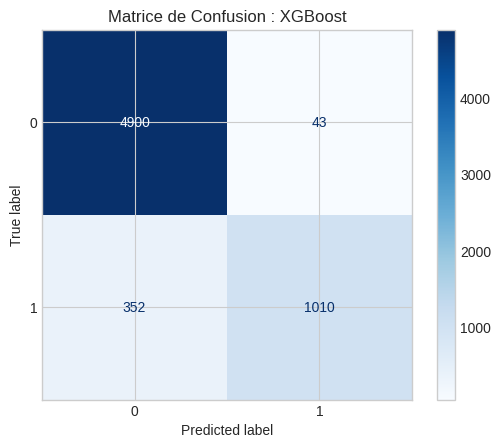

In [ ]:
# Matrice de confusion
y_pred_xgb = trained_pipelines["XGBoost"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion : XGBoost")
plt.show()

## Explication des données du dataset pour le refus ou l'accord de l'attribution des crédits.

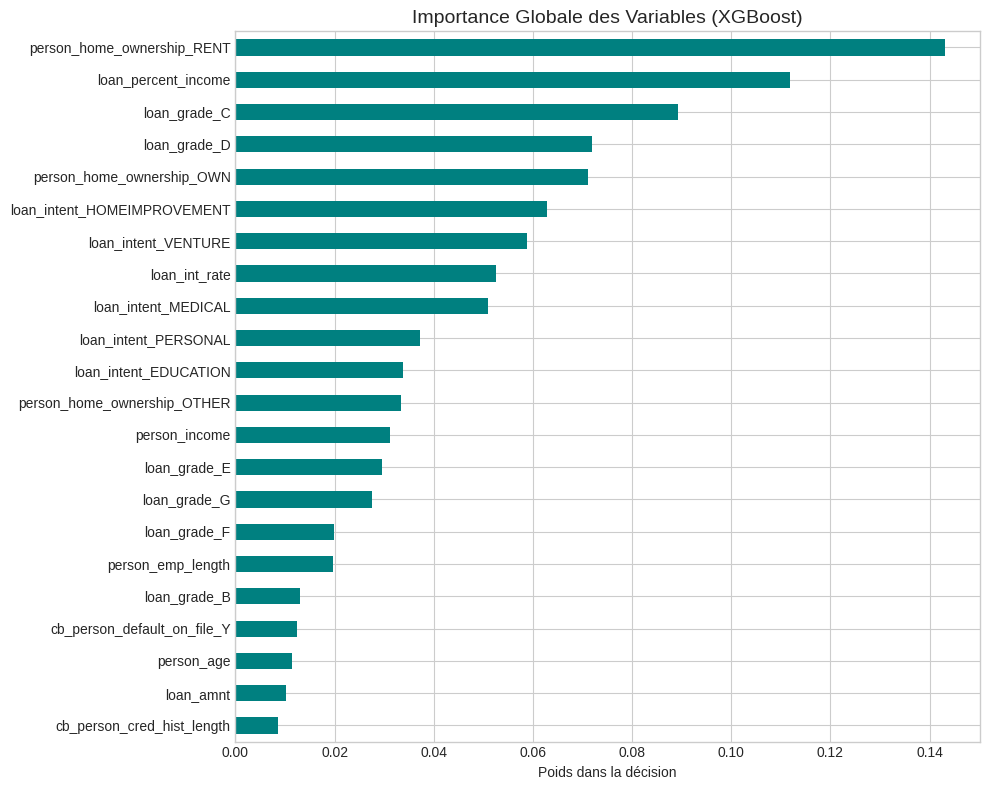

In [ ]:
# Récupération du meilleur modèle XGBoost
best_pipeline = trained_pipelines["XGBoost"]
best_xgb = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline.named_steps['preprocessor']

# Récupération propre des noms de colonnes
num_features = credit_dataset_num_cols 
cat_transformer = preprocessor.transformers_[1][1]
cat_features = list(cat_transformer.steps[-1][1].get_feature_names_out(cat_cols))
features = num_features + cat_features

# Création de la série d'importances
feat_importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=True)

# Affichage du graphique
plt.figure(figsize=(10, 8))
feat_importances.plot(kind='barh', color='teal')
plt.title("Importance Globale des Variables (XGBoost)", fontsize=14)
plt.xlabel("Poids dans la décision")
plt.tight_layout()
plt.show()

loan_status                   0         1
person_home_ownership                    
MORTGAGE               0.875019  0.124981
OTHER                  0.688679  0.311321
OWN                    0.930573  0.069427
RENT                   0.688824  0.311176


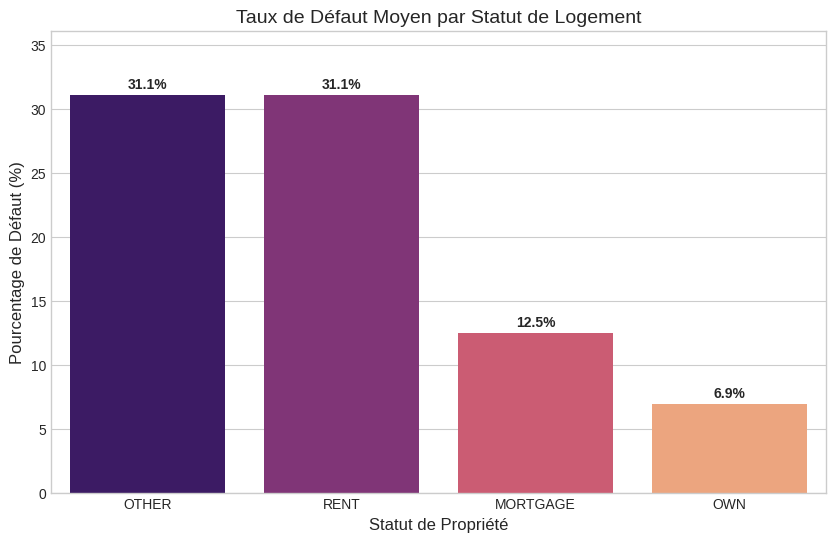

In [ ]:
# Pour vérifier la théorie par les chiffres :
print(pd.crosstab(credit_dataset['person_home_ownership'], credit_dataset['loan_status'], normalize='index'))

# 1. Calcul du taux de défaut par catégorie de logement
# On fait la moyenne de 'loan_status' (car 1 = défaut, 0 = remboursé)
# La moyenne nous donne donc directement le % de défaut.
home_risk = credit_dataset.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False) * 100

# 2. Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=home_risk.index, y=home_risk.values, palette='magma', hue=home_risk.index, legend=False)

# 3. Cosmétique
plt.title("Taux de Défaut Moyen par Statut de Logement", fontsize=14)
plt.ylabel("Pourcentage de Défaut (%)", fontsize=12)
plt.xlabel("Statut de Propriété", fontsize=12)
plt.ylim(0, max(home_risk.values) + 5) # Laisser de la place pour les étiquettes

# Ajout des pourcentages au-dessus des barres
for i, v in enumerate(home_risk.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

## Test final sur un pool de 10 personnes générées aléatoirement

In [ ]:
# ==========================================
#  GÉNÉRATION DES 10 NOUVEAUX CLIENTS
# ==========================================
def generate_random_customers(n=10):
    np.random.seed(42) 
    data = {
        'person_age': np.random.randint(20, 65, n),
        'person_income': np.random.randint(15000, 120000, n),
        'person_home_ownership': np.random.choice(['RENT', 'MORTGAGE', 'OWN'], n),
        'person_emp_length': np.random.uniform(0, 15, n).round(1),
        'loan_intent': np.random.choice(['EDUCATION', 'MEDICAL', 'VENTURE', 'PERSONAL', 'DEBTCONSOLIDATION'], n),
        'loan_grade': np.random.choice(['A', 'B', 'C', 'D', 'E'], n),
        'loan_amnt': np.random.randint(1000, 30000, n),
        'loan_int_rate': np.random.uniform(5.0, 22.0, n).round(2),
        'cb_person_default_on_file': np.random.choice(['Y', 'N'], n),
        'cb_person_cred_hist_length': np.random.randint(2, 20, n)
    }
    df = pd.DataFrame(data)
    df['loan_percent_income'] = (df['loan_amnt'] / df['person_income']).round(2)
    return df

new_customers_df = generate_random_customers(10)

# ==========================================
#  CALCUL DES SCORES VIA LE PIPELINE
# ==========================================
best_pipeline = trained_pipelines["XGBoost"]
scores = best_pipeline.predict_proba(new_customers_df)[:, 1]

# ==========================================
#  BOUCLE D'ANALYSE DÉTAILLÉE (LES 10 CLIENTS)
# ==========================================
print("\n" + "="*95)
print(f"{'ID':<4} | {'RISQUE':<8} | {'DÉCISION':<12} | {'ANALYSE DES FACTEURS CLÉS'}")
print("-" * 95)

for i in range(len(new_customers_df)):
    row = new_customers_df.iloc[i]
    current_score = scores[i] * 100
    
    # Seuil bancaire à 40%
    decision = "❌ REFUSÉ" if current_score > 40 else "✅ ACCORDÉ"
    reasons = []
    
    # Facteur 1 : Endettement (Ratio prêt/revenu)
    if row['loan_percent_income'] > 0.35:
        reasons.append(f"Endettement critique ({row['loan_percent_income']:.0%})")
    elif row['loan_percent_income'] > 0.20:
        reasons.append(f"Endettement élevé ({row['loan_percent_income']:.0%})")
        
    # Facteur 2 : Taux d'intérêt
    if row['loan_int_rate'] > 15:
        reasons.append(f"Taux d'intérêt prohibitif ({row['loan_int_rate']}%)")
    elif row['loan_int_rate'] < 8:
        reasons.append("Taux préférentiel (Profil sûr)")

    # Facteur 3 : Revenus
    if row['person_income'] < 25000:
        reasons.append("Faibles revenus")
    elif row['person_income'] > 85000:
        reasons.append("Revenus confortables")

    # Facteur 4 : Logement
    if row['person_home_ownership'] == 'RENT' and current_score > 50:
        reasons.append("Statut locataire (Facteur aggravant)")
    elif row['person_home_ownership'] == 'OWN':
        reasons.append("Propriétaire (Garantie)")

    explication = " / ".join(reasons) if reasons else "Profil standard sans alertes"
    
    print(f"{i+1:<4} | {current_score:>6.1f}% | {decision:<12} | {explication}")

print("="*95)


ID   | RISQUE   | DÉCISION     | ANALYSE DES FACTEURS CLÉS
-----------------------------------------------------------------------------------------------
1    |   56.9% | ❌ REFUSÉ     | Revenus confortables
2    |    0.2% | ✅ ACCORDÉ    | Profil standard sans alertes
3    |   82.6% | ❌ REFUSÉ     | Endettement critique (37%) / Taux d'intérêt prohibitif (21.48%)
4    |   78.6% | ❌ REFUSÉ     | Taux d'intérêt prohibitif (18.18%) / Statut locataire (Facteur aggravant)
5    |   97.0% | ❌ REFUSÉ     | Taux d'intérêt prohibitif (20.97%) / Statut locataire (Facteur aggravant)
6    |   15.9% | ✅ ACCORDÉ    | Endettement élevé (30%) / Taux d'intérêt prohibitif (20.21%)
7    |   33.5% | ✅ ACCORDÉ    | Endettement élevé (26%) / Taux d'intérêt prohibitif (15.16%)
8    |   61.1% | ❌ REFUSÉ     | Taux d'intérêt prohibitif (20.67%) / Faibles revenus / Statut locataire (Facteur aggravant)
9    |    4.5% | ✅ ACCORDÉ    | Taux préférentiel (Profil sûr)
10   |    1.5% | ✅ ACCORDÉ    | Profil standard s